# Image filters


## Lab 1


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Leer la imagen
img = cv2.imread("liam.jpeg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [20]:
def plot_img(img, title="Imagen", cmap=None):
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

<class 'numpy.ndarray'>
(2250, 4000, 3)


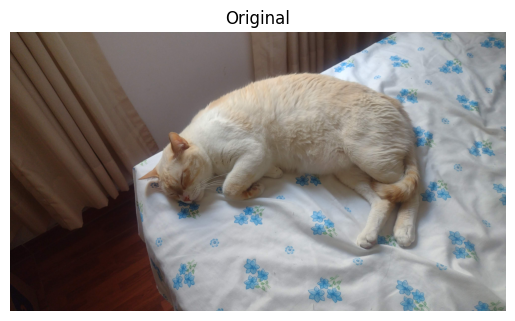

In [23]:
print(type(img))
print(img.shape)

plot_img(img, "Original")

<class 'numpy.ndarray'>
(2250, 4000)


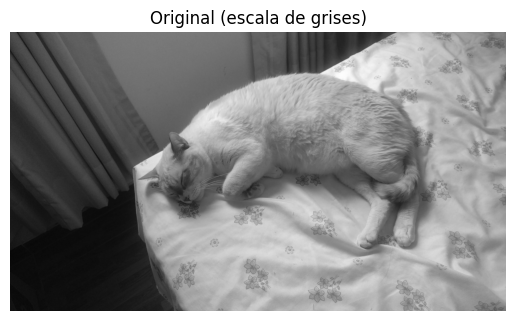

In [26]:
print(type(img_gray))
print(img_gray.shape)

plot_img(img_gray, "Original (escala de grises)", cmap="gray")

## Brillo


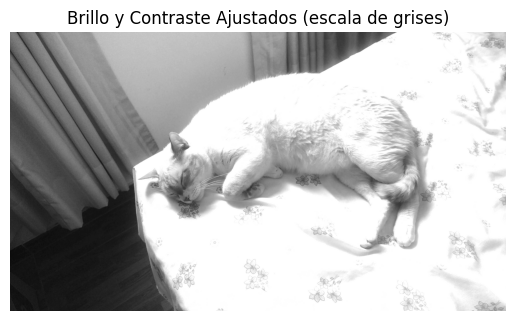

In [48]:
# Parámetros de brillo y contraste
beta = 100  # Brillo (0 = sin cambio, >0 más brillo)

# Aplicar brillo y contraste: nuevo_pixel = alpha * pixel + beta
adjusted = cv2.convertScaleAbs(img_gray, alpha=1, beta=beta)

plot_img(adjusted, "Brillo y Contraste Ajustados (escala de grises)", cmap="gray")

## Contraste


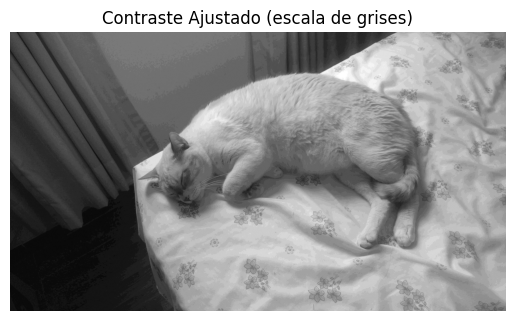

In [45]:
# Ajuste de contraste con alpha (sin modificar brillo)
alpha = 0.1  # >1 más contraste, <1 menos contraste

contrasted = cv2.convertScaleAbs(img_gray, alpha=alpha, beta=0)

plot_img(contrasted, "Contraste Ajustado (escala de grises)", cmap="gray")

## Histograma


### Brillo


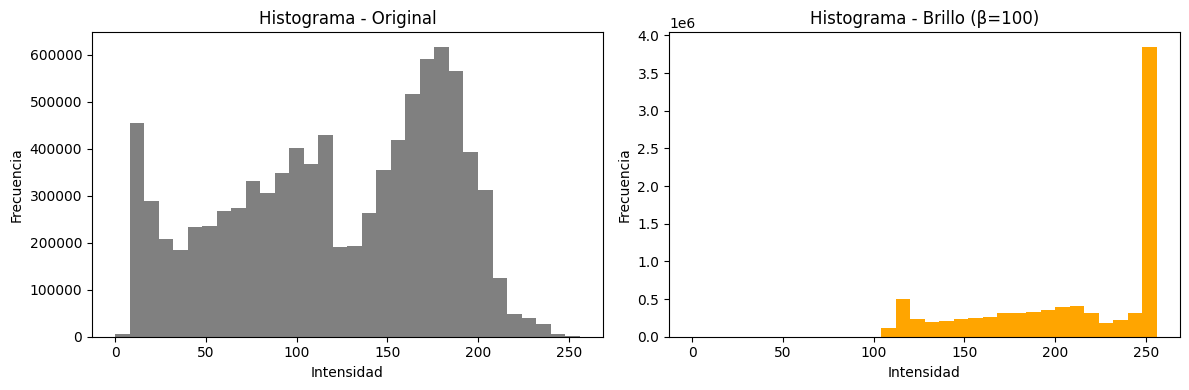

In [49]:
# Histograma: original vs brillo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_gray.ravel(), bins=32, range=(0, 256), color="gray")
axes[0].set_title("Histograma - Original")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(adjusted.ravel(), bins=32, range=(0, 256), color="orange")
axes[1].set_title(f"Histograma - Brillo (β={beta})")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Contraste


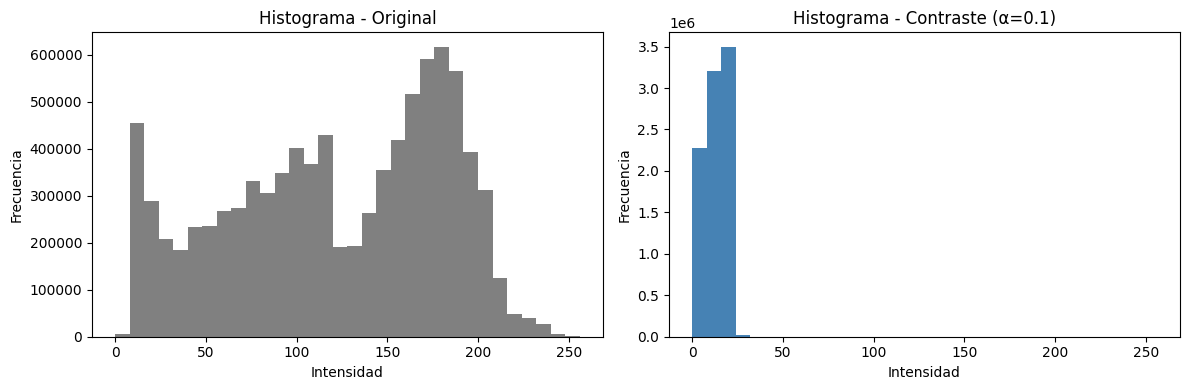

In [47]:
# Histograma: original vs contraste
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(img_gray.ravel(), bins=32, range=(0, 256), color="gray")
axes[0].set_title("Histograma - Original")
axes[0].set_xlabel("Intensidad")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(contrasted.ravel(), bins=32, range=(0, 256), color="steelblue")
axes[1].set_title(f"Histograma - Contraste (α={alpha})")
axes[1].set_xlabel("Intensidad")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Lab 2: Ecualización de histograma


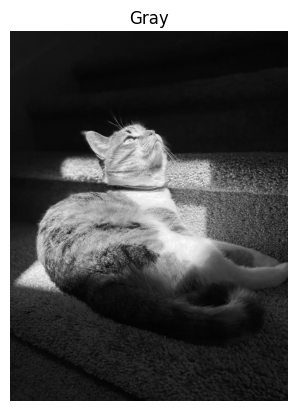

In [61]:
img = cv2.imread("kitty.webp")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plot_img(img_gray, "Gray", cmap="gray")

### Con OpenCV


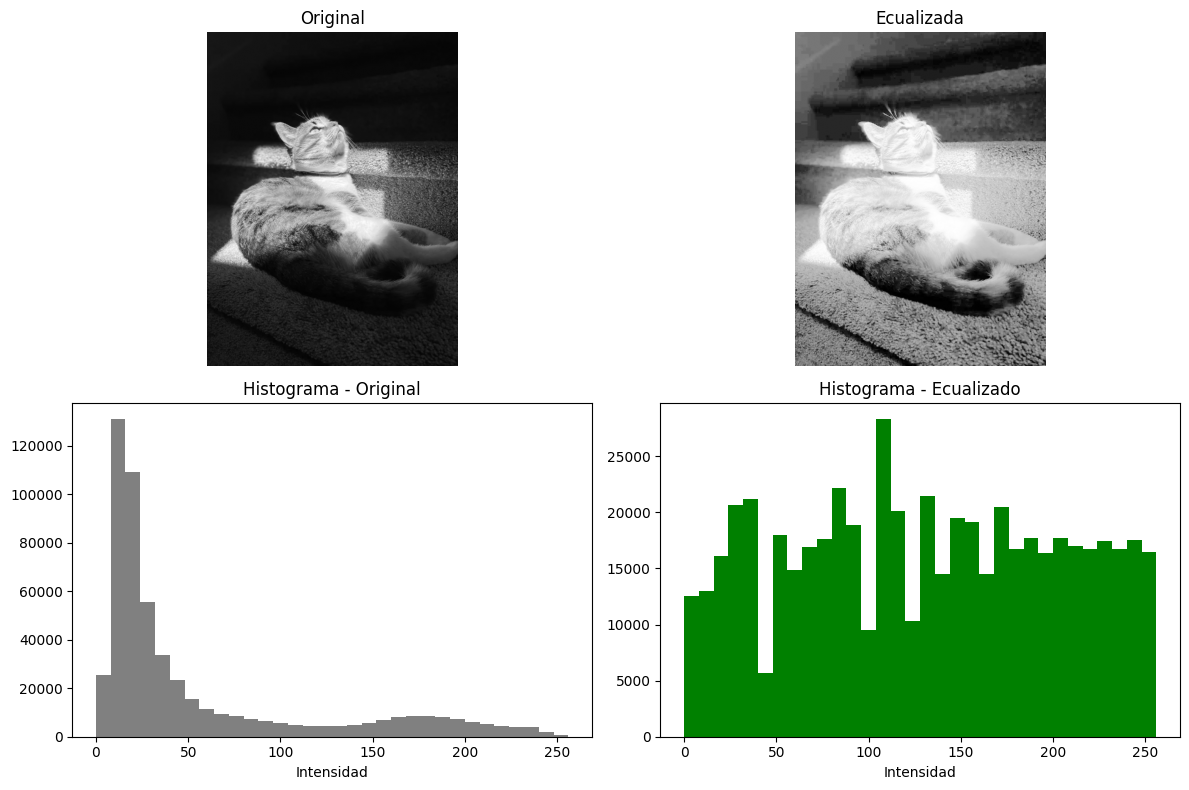

In [62]:
# Ecualización de histograma con OpenCV
img_eq = cv2.equalizeHist(img_gray)

# Mostrar resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_eq, cmap="gray")
axes[0, 1].set_title("Ecualizada")
axes[0, 1].axis("off")

axes[1, 0].hist(img_gray.ravel(), bins=32, range=(0, 256), color="gray")
axes[1, 0].set_title("Histograma - Original")
axes[1, 0].set_xlabel("Intensidad")

axes[1, 1].hist(img_eq.ravel(), bins=32, range=(0, 256), color="green")
axes[1, 1].set_title("Histograma - Ecualizado")
axes[1, 1].set_xlabel("Intensidad")

plt.tight_layout()
plt.show()

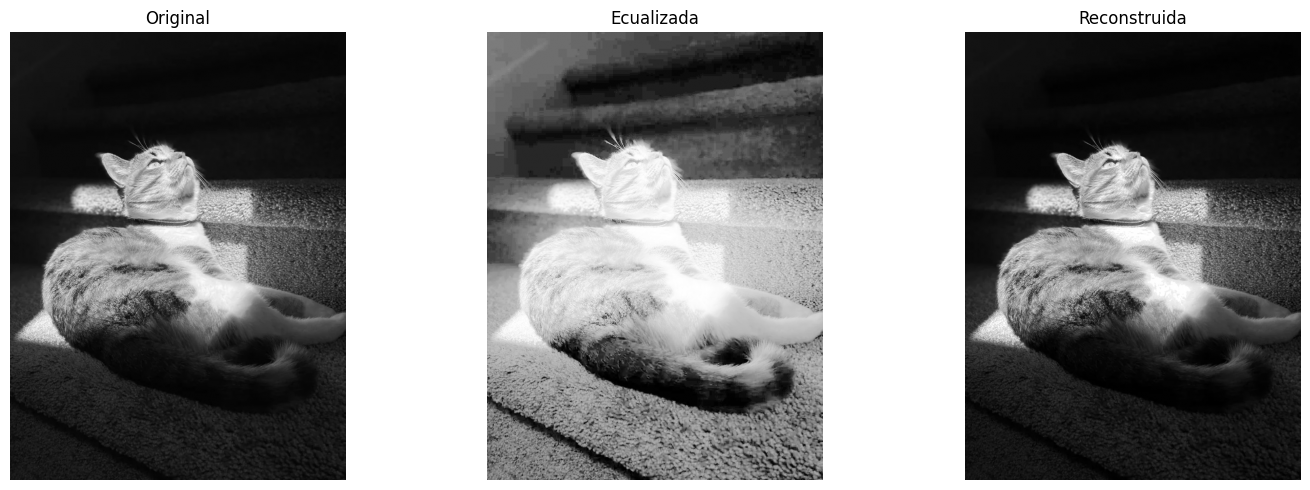

Error promedio de reconstrucción: 0.69 niveles de intensidad


In [63]:
# Reconstrucción: de imagen ecualizada a imagen original

# 1. Calcular el mapeo de ecualización (intensidad original -> intensidad ecualizada)
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
cdf = hist.cumsum()
cdf_norm = cdf / img_gray.size
mapping = np.floor(cdf_norm * 255).astype(np.uint8)

# 2. Construir el mapeo inverso (intensidad ecualizada -> intensidad original)
# Como varios valores originales pueden mapear al mismo ecualizado,
# usamos el promedio de los originales que comparten esa intensidad ecualizada
inverse_map = np.zeros(256, dtype=np.uint8)
for orig_val in range(256):
    eq_val = mapping[orig_val]
    # Guardar el último valor original que mapea a cada ecualizado
    inverse_map[eq_val] = orig_val

# Interpolar los huecos (valores ecualizados sin mapeo directo)
for i in range(1, 256):
    if inverse_map[i] == 0 and i not in mapping:
        inverse_map[i] = inverse_map[i - 1]

# 3. Aplicar el mapeo inverso para reconstruir
img_reconstructed = inverse_map[img_eq]

# Mostrar: original vs ecualizada vs reconstruida
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(img_eq, cmap="gray")
axes[1].set_title("Ecualizada")
axes[1].axis("off")

axes[2].imshow(img_reconstructed, cmap="gray")
axes[2].set_title("Reconstruida")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Error de reconstrucción
error = np.mean(np.abs(img_gray.astype(float) - img_reconstructed.astype(float)))
print(f"Error promedio de reconstrucción: {error:.2f} niveles de intensidad")

### Handmade


#### Histograma


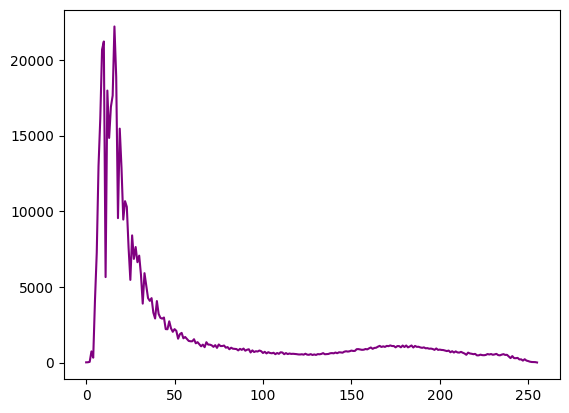

In [ ]:
hist = cv2.calcHist([img_gray], [0], None, [256], [0, 256]).flatten()
plt.plot(hist, color="purple")

### CDF


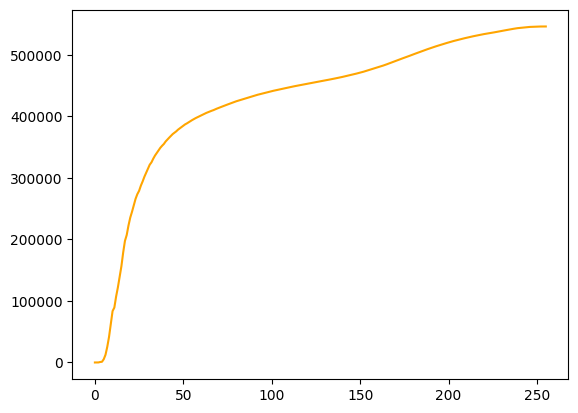

In [69]:
cdf = hist.cumsum()
plt.plot(cdf, color="orange")

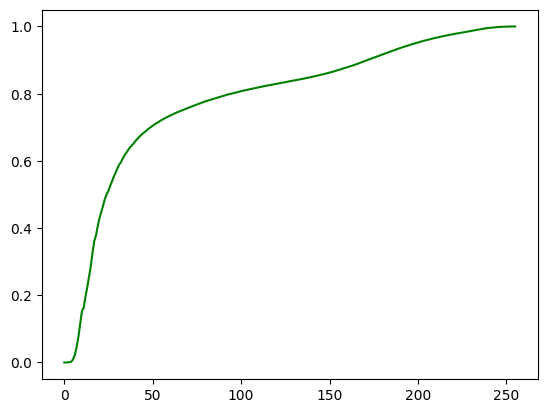

In [ ]:
cdf_norm = cdf / img_gray.size
plt.plot(cdf_norm, color="green")

#### Reasignar intensidades

$Nueva\ intensidad[k] = \lfloor CDF_{norm}[k] \cdot (L-1) \rfloor$


[  0   0   0   0   0   2   5  11  19  29  39  41  50  56  64  73  83  92
  96 103 109 114 119 124 127 130 134 137 140 144 147 150 151 154 157 159
 160 162 164 165 167 169 170 171 173 174 175 176 177 178 179 180 181 182
 183 183 184 185 186 186 187 188 188 189 189 190 191 191 192 192 193 193
 194 194 195 195 196 196 197 197 198 198 199 199 199 200 200 201 201 202
 202 202 203 203 203 204 204 204 205 205 205 206 206 206 207 207 207 207
 208 208 208 209 209 209 209 210 210 210 211 211 211 211 212 212 212 212
 213 213 213 213 214 214 214 214 215 215 215 215 216 216 216 217 217 217
 217 218 218 218 219 219 219 220 220 221 221 221 222 222 223 223 223 224
 224 225 225 226 226 227 227 228 228 229 229 230 230 231 231 232 232 233
 233 234 234 235 235 236 236 237 237 238 238 239 239 239 240 240 241 241
 242 242 242 243 243 244 244 244 245 245 245 246 246 246 247 247 247 247
 248 248 248 248 249 249 249 249 250 250 250 250 251 251 251 251 252 252
 252 252 253 253 253 253 253 254 254 254 254 254 25

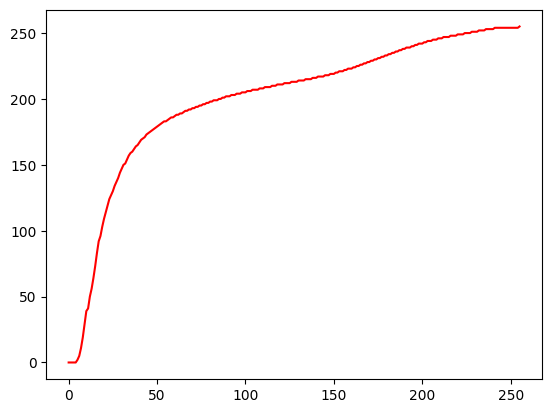

In [80]:
# 4. Reasignar intensidades: nueva_intensidad[k] = floor(CDF_norm[k] * (L-1))
L = 256
new_intensity = np.floor(cdf_norm * (L - 1)).astype(np.uint8)

print(new_intensity)

plt.plot(new_intensity, color="red")

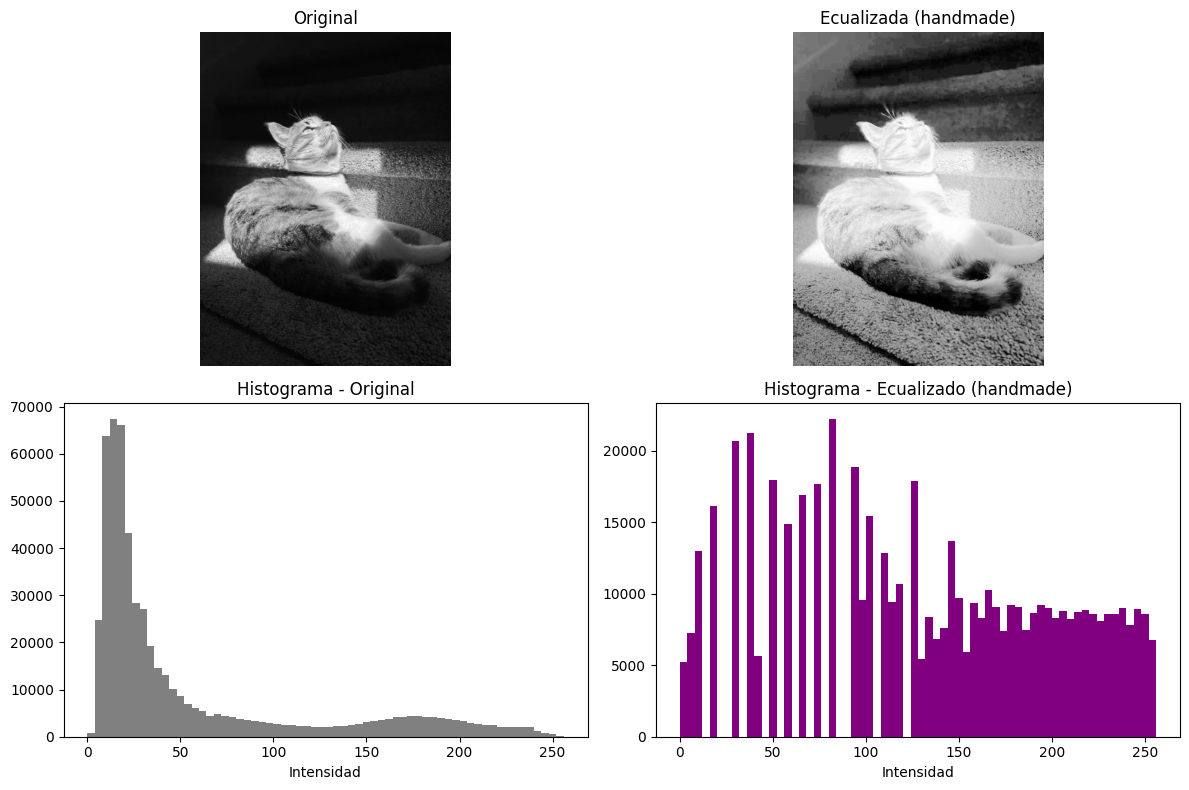

In [74]:
# 5. Construir la imagen ecualizada
img_eq_handmade = new_intensity[img_gray.astype(int)]

# Mostrar resultado
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img_gray, cmap="gray")
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_eq_handmade, cmap="gray")
axes[0, 1].set_title("Ecualizada (handmade)")
axes[0, 1].axis("off")

axes[1, 0].hist(img_gray.ravel(), bins=64, range=(0, 256), color="gray")
axes[1, 0].set_title("Histograma - Original")
axes[1, 0].set_xlabel("Intensidad")

axes[1, 1].hist(img_eq_handmade.ravel(), bins=64, range=(0, 256), color="purple")
axes[1, 1].set_title("Histograma - Ecualizado (handmade)")
axes[1, 1].set_xlabel("Intensidad")

plt.tight_layout()
plt.show()